# Customer Retention Intelligence
## Telecom Customer Churn Analytics and Prediction

**Author:** Abhay Pratap Singh  
**Project:** IBM Data Analytics internship final project

### 1. Business problem and objectives
Customer churn reduces the customer base and creates a need for replacement sales.
This project examines which customer groups have higher observed churn, develops an
interpretable Logistic Regression classifier, and proposes measurable retention actions.

**Analysis flow:** raw data → understanding → cleaning → exploration → KPIs →
churn associations → risk and opportunities → prediction → recommendations.

The questions are:
1. How common is churn in the supplied customer snapshot?
2. How does churn vary with tenure, contracts, charges, services, and payment methods?
3. How well does Logistic Regression distinguish churned from non-churned customers?
4. Which held-out customers would be prioritized at a predicted probability of at least 0.50?

The first four headline KPIs describe the full dataset. **High-Risk Customer Count**
is calculated later from **held-out test customers only**, after prediction. It is
not a count for the full customer base. Observational patterns and model coefficients
describe associations, not causes. The dataset contains no dates defining a future
prediction horizon. Monetary fields are reported as **charge units; currency is unspecified**.

### How to run
Open this notebook from the project root with the supplied CSV in the `data` folder.
Use a Python kernel with pandas, NumPy, Matplotlib, seaborn, and scikit-learn installed,
then restart the kernel and run all cells from top to bottom. No external data or
network access is needed to run the analysis. Figures and results are embedded here.

### 2. Setup and data loading
Set a fixed random seed and consistent chart formatting. Package versions are displayed
to make the execution environment visible. A convergence warning is treated as an error
so an unconverged model cannot silently become the reported result.

In [1]:
%matplotlib inline
from pathlib import Path
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import sklearn
from IPython.display import display, Markdown, HTML
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
THRESHOLD = 0.50
DATA_PATH = Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
warnings.filterwarnings("error", category=ConvergenceWarning)

RETAINED_COLOR = "#356B87"
CHURN_COLOR = "#BB593F"
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (9, 5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlepad": 14,
    "grid.alpha": 0.25,
})
pd.set_option("display.max_columns", 25)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.3f}".format)

def show_table(table, formats=None, index=True):
    """Format a display copy without changing the underlying calculated values."""
    formatted = table.copy()
    for column, pattern in (formats or {}).items():
        formatted[column] = formatted[column].map(pattern.format)
    display(HTML(formatted.to_html(index=index, escape=True)))

versions = pd.Series({
    "Python": platform.python_version(), "pandas": pd.__version__,
    "NumPy": np.__version__, "Matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__, "scikit-learn": sklearn.__version__,
}, name="Version")
display(versions.to_frame())

if not DATA_PATH.is_file():
    raise FileNotFoundError("Run from the project root with the CSV in the data folder.")
raw = pd.read_csv(DATA_PATH)
print(f"Loaded {len(raw):,} rows and {raw.shape[1]} columns.")
display(raw.head())

,Version
Python,3.12.14
pandas,3.0.6
NumPy,2.5.3
Matplotlib,3.11.2
seaborn,0.13.2
scikit-learn,1.9.1


Loaded 7,043 rows and 21 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


### 3. Data understanding
Each record describes a customer. `customerID` is an identifier and `Churn` is the
outcome. Tenure is measured in months. `SeniorCitizen` is a binary category even
though its stored values are numeric. The table combines definitions with the
actual imported data types and distinct-value counts.

In [2]:
definitions = {
    "customerID": "Customer identifier; excluded from predictors",
    "gender": "Recorded gender category",
    "SeniorCitizen": "Senior-citizen indicator: 0 or 1",
    "Partner": "Whether the customer has a partner",
    "Dependents": "Whether the customer has dependents",
    "tenure": "Customer tenure in months",
    "PhoneService": "Whether phone service is present",
    "MultipleLines": "Multiple-line subscription or no phone service",
    "InternetService": "DSL, fiber optic, or no internet service",
    "OnlineSecurity": "Online-security subscription status",
    "OnlineBackup": "Online-backup subscription status",
    "DeviceProtection": "Device-protection subscription status",
    "TechSupport": "Technical-support subscription status",
    "StreamingTV": "Streaming-TV subscription status",
    "StreamingMovies": "Streaming-movies subscription status",
    "Contract": "Month-to-month, one-year, or two-year contract",
    "PaperlessBilling": "Whether billing is paperless",
    "PaymentMethod": "Recorded payment method",
    "MonthlyCharges": "Monthly charges; currency unspecified",
    "TotalCharges": "Accumulated charges; currency unspecified",
    "Churn": "Observed churn status: Yes or No",
}
assert set(raw.columns) == set(definitions), "Unexpected dataset schema."
data_dictionary = pd.DataFrame({
    "Description": pd.Series(definitions),
    "Imported dtype": raw.dtypes.astype(str),
    "Distinct values": raw.nunique(dropna=False),
})
display(data_dictionary)

numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
feature_columns = [column for column in raw.columns if column not in ["customerID", "Churn"]]
categorical_features = [column for column in feature_columns if column not in numerical_features]
print(f"Predictors: {len(numerical_features)} numerical and {len(categorical_features)} categorical.")

,Description,Imported dtype,Distinct values
customerID,Customer identifier; excluded from predictors,str,7043
gender,Recorded gender category,str,2
SeniorCitizen,Senior-citizen indicator: 0 or 1,int64,2
Partner,Whether the customer has a partner,str,2
Dependents,Whether the customer has dependents,str,2
tenure,Customer tenure in months,int64,73
PhoneService,Whether phone service is present,str,2
MultipleLines,Multiple-line subscription or no phone service,str,3
InternetService,"DSL, fiber optic, or no internet service",str,3
OnlineSecurity,Online-security subscription status,str,3


Predictors: 3 numerical and 16 categorical.


### 4. Data quality and cleaning
Check both conventional missing values and whitespace-only entries before changing data.
`No internet service` and `No phone service` are valid categories and are retained.
Duplicate customer IDs would invalidate a customer-level split, so they are checked explicitly.

In [3]:
text_columns = raw.select_dtypes(include=["object", "string"]).columns
blank_counts = pd.Series(0, index=raw.columns, dtype="int64")
for column in text_columns:
    blank_counts[column] = raw[column].astype("string").str.strip().eq("").sum()

quality_before = pd.DataFrame({
    "Missing values": raw.isna().sum(),
    "Whitespace-only values": blank_counts,
})
display(quality_before)
print(f"Exact duplicate rows: {raw.duplicated().sum():,}")
print(f"Duplicate customer IDs: {raw['customerID'].duplicated().sum():,}")

,Missing values,Whitespace-only values
customerID,0,0
gender,0,0
SeniorCitizen,0,0
Partner,0,0
Dependents,0,0
tenure,0,0
PhoneService,0,0
MultipleLines,0,0
InternetService,0,0
OnlineSecurity,0,0


Exact duplicate rows: 0
Duplicate customer IDs: 0


**Cleaning assumption:** convert `TotalCharges` to numeric and replace missing values
with zero **only when tenure equals zero**. This assumes that accumulated charges
have not yet been recorded for those new customers; it is not a fact established by
the CSV. Missing charges at positive tenure or unexpected invalid text would require
investigation and will raise an error. This rule uses no learned statistic or target
information, so it can be applied before splitting. Scaling and encoding are fitted later
using training records only. No valid records are removed.

In [4]:
df = raw.copy(deep=True)
for column in text_columns:
    df[column] = df[column].astype("string").str.strip()

total_charge_text = df["TotalCharges"].copy()
df["TotalCharges"] = pd.to_numeric(total_charge_text, errors="coerce")
unexpected_text = total_charge_text.notna() & total_charge_text.ne("") & df["TotalCharges"].isna()
assert not unexpected_text.any(), "Unexpected non-numeric TotalCharges value."
missing_total = df["TotalCharges"].isna()
zero_tenure_missing = missing_total & df["tenure"].eq(0)
assert not (missing_total & df["tenure"].ne(0)).any(), "Investigate charges missing at positive tenure."

cleaned_charge_count = int(zero_tenure_missing.sum())
df.loc[zero_tenure_missing, "TotalCharges"] = 0.0
assert set(df["SeniorCitizen"].unique()) <= {0, 1}
df["SeniorCitizen"] = df["SeniorCitizen"].astype(str)
assert set(df["Churn"].unique()) == {"No", "Yes"}
df["ChurnFlag"] = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)

assert df[raw.columns].notna().all().all(), "Unexpected missing values remain."
assert df["customerID"].is_unique and not df.duplicated().any()
assert (df[numerical_features] >= 0).all().all()
assert df["tenure"].eq(df["tenure"].round()).all()
assert ((df["PhoneService"] == "No") == (df["MultipleLines"] == "No phone service")).all()
internet_addons = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for column in internet_addons:
    assert ((df["InternetService"] == "No") == (df[column] == "No internet service")).all()

display(Markdown(
    f"Converted **TotalCharges** to numeric and filled **{cleaned_charge_count:,}** "
    f"zero-tenure blanks with zero under the documented assumption. "
    f"Retained **{len(df):,}** customers; **{int(df[raw.columns].isna().sum().sum())}** missing values remain."
))
display(df[numerical_features].describe().round(2))
display(pd.DataFrame({
    "Categorical feature": categorical_features,
    "Observed categories": [", ".join(sorted(df[column].unique())) for column in categorical_features],
}))

Converted **TotalCharges** to numeric and filled **11** zero-tenure blanks with zero under the documented assumption. Retained **7,043** customers; **0** missing values remain.

,tenure,MonthlyCharges,TotalCharges
count,"7,043.000","7,043.000","7,043.000"
mean,32.370,64.760,"2,279.730"
std,24.560,30.090,"2,266.790"
min,0.000,18.250,0.000
25%,9.000,35.500,398.550
50%,29.000,70.350,"1,394.550"
75%,55.000,89.850,"3,786.600"
max,72.000,118.750,"8,684.800"


,Categorical feature,Observed categories
0,gender,"Female, Male"
1,SeniorCitizen,"0, 1"
2,Partner,"No, Yes"
3,Dependents,"No, Yes"
4,PhoneService,"No, Yes"
5,MultipleLines,"No, No phone service, Yes"
6,InternetService,"DSL, Fiber optic, No"
7,OnlineSecurity,"No, No internet service, Yes"
8,OnlineBackup,"No, No internet service, Yes"
9,DeviceProtection,"No, No internet service, Yes"


### 5. Descriptive KPI summary
These four measures use all customers in the supplied snapshot. The observed churn
rate is the fraction labeled `Yes`; it is not an annual or monthly churn estimate.
The fifth KPI, **High-Risk Customer Count**, is calculated after held-out prediction
and presented with these four measures in the final KPI table in Section 12.

In [5]:
total_customers = len(df)
observed_churn_rate = df["ChurnFlag"].mean()
average_monthly_charges = df["MonthlyCharges"].mean()
average_tenure = df["tenure"].mean()
descriptive_kpis = pd.DataFrame({
    "KPI": ["Total Customers", "Observed Churn Rate", "Average Monthly Charges", "Average Tenure"],
    "Value": [f"{total_customers:,}", f"{observed_churn_rate:.2%}",
              f"{average_monthly_charges:.2f} charge units", f"{average_tenure:.2f} months"],
})
display(descriptive_kpis)

,KPI,Value
0,Total Customers,"7,043"
1,Observed Churn Rate,26.54%
2,Average Monthly Charges,64.76 charge units
3,Average Tenure,32.37 months


### 6. Exploratory data analysis
The charts describe the full snapshot. Group rates always use the number of customers
in that group as the denominator; customer counts are shown to prevent a small group
from appearing more important simply because of its rate. These descriptive views do
not select model parameters, features, or the classification threshold using test results.

#### Figure 1. How common is churn?

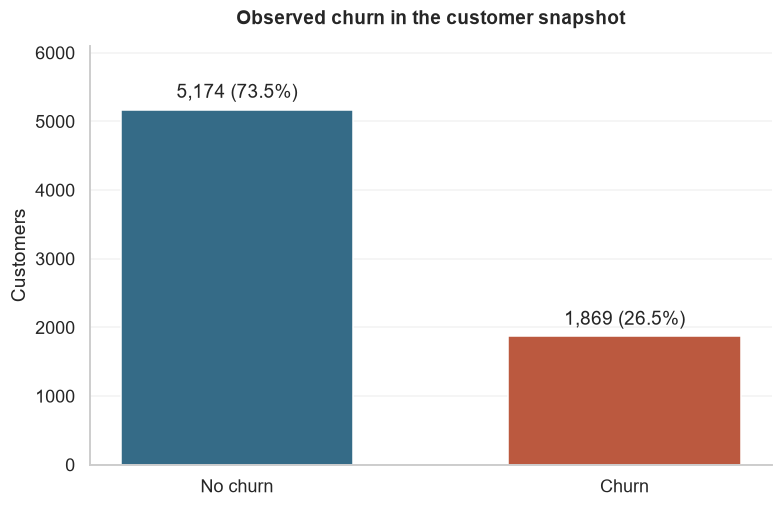

**1,869 of 7,043 customers (26.54%)** are labeled as churned. The class imbalance makes recall and precision important alongside accuracy.

In [6]:
churn_counts = df["Churn"].value_counts().reindex(["No", "Yes"])
fig, ax = plt.subplots(figsize=(7, 4.5), layout="constrained")
bars = ax.bar(["No churn", "Churn"], churn_counts, color=[RETAINED_COLOR, CHURN_COLOR], width=0.6)
ax.bar_label(bars, labels=[f"{count:,} ({count / total_customers:.1%})" for count in churn_counts], padding=5)
ax.set(title="Observed churn in the customer snapshot", ylabel="Customers", ylim=(0, churn_counts.max() * 1.18))
ax.grid(axis="x", visible=False)
plt.show()
display(Markdown(
    f"**{churn_counts['Yes']:,} of {total_customers:,} customers ({observed_churn_rate:.2%})** "
    "are labeled as churned. The class imbalance makes recall and precision important alongside accuracy."
))

#### Figure 2. Churn by contract
A reusable group summary keeps churn calculations consistent. The dashed line marks
the overall observed churn rate. Differences between contracts may reflect tenure,
customer selection, and other factors; they do not establish a contract's causal effect.

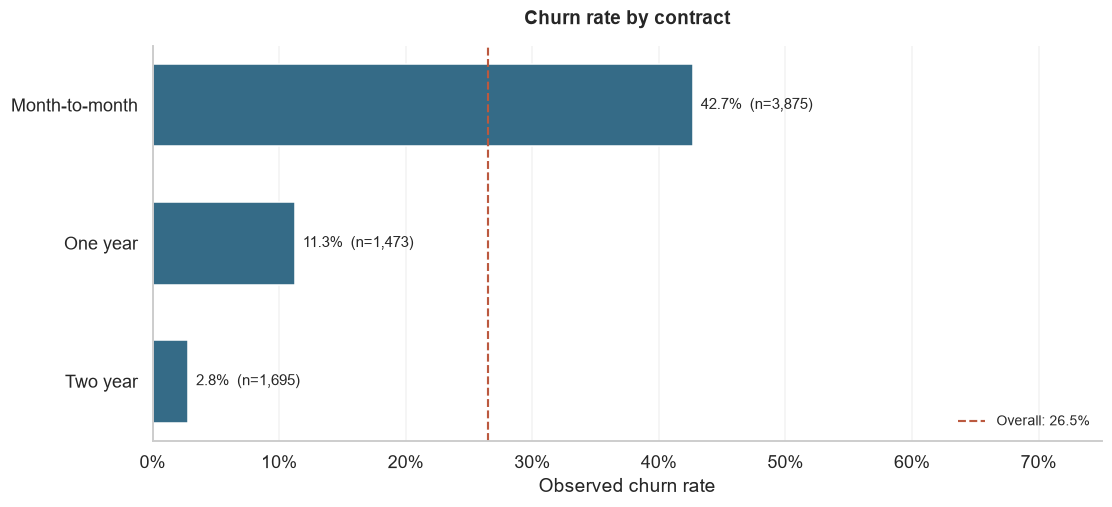

,Customers,Churned,ChurnRate
Contract,,,
Month-to-month,"3,875","1,655",42.71%
One year,"1,473",166,11.27%
Two year,"1,695",48,2.83%


In [7]:
def segment_summary(column):
    """Customer count, churn count, and churn rate for each observed category."""
    return df.groupby(column, observed=True)["ChurnFlag"].agg(
        Customers="size", Churned="sum", ChurnRate="mean"
    )

def plot_segment_rates(summary, ax, title):
    """Plot group rates with customer counts and the overall rate as context."""
    positions = np.arange(len(summary))
    bars = ax.barh(positions, summary["ChurnRate"], color=RETAINED_COLOR, height=0.6)
    ax.set_yticks(positions, [str(label) for label in summary.index])
    ax.invert_yaxis()
    ax.bar_label(bars, labels=[
        f"{row.ChurnRate:.1%}  (n={row.Customers:,.0f})" for row in summary.itertuples()
    ], padding=5, fontsize=10)
    ax.axvline(observed_churn_rate, color=CHURN_COLOR, linestyle="--", linewidth=1.4,
               label=f"Overall: {observed_churn_rate:.1%}")
    ax.set(title=title, xlabel="Observed churn rate", ylabel="", xlim=(0, 0.75))
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(axis="y", visible=False)
    ax.legend(loc="lower right", fontsize=9, frameon=False)

contract_summary = segment_summary("Contract").reindex(["Month-to-month", "One year", "Two year"])
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
plot_segment_rates(contract_summary, ax, "Churn rate by contract")
plt.show()
show_table(contract_summary, {"Customers": "{:,.0f}", "Churned": "{:,.0f}", "ChurnRate": "{:.2%}"})

#### Figure 3. Churn across tenure bands
Use bands for explanation, while preserving original numerical tenure for modeling.
Zero-tenure customers belong to the first band. These are cross-sectional comparisons,
not a tracked cohort or a survival analysis.

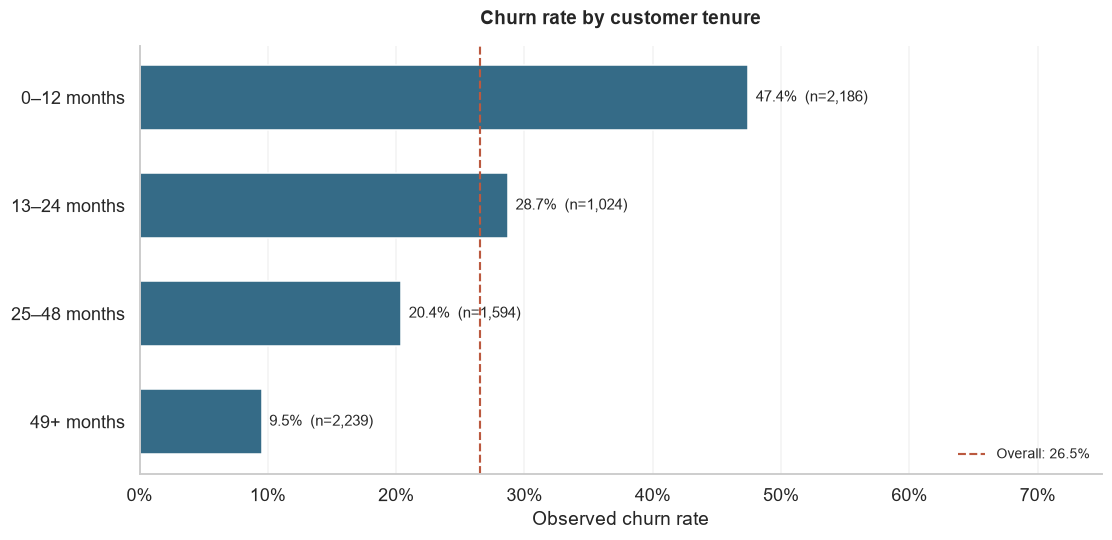

Observed churn is **47.44%** in the first tenure band and **9.51%** in the longest-tenure band. This identifies early-tenure customers as a segment to investigate for onboarding support.

In [8]:
df["TenureBand"] = pd.cut(
    df["tenure"], bins=[-1, 12, 24, 48, np.inf],
    labels=["0–12 months", "13–24 months", "25–48 months", "49+ months"],
)
tenure_summary = segment_summary("TenureBand")
fig, ax = plt.subplots(figsize=(10, 4.8), layout="constrained")
plot_segment_rates(tenure_summary, ax, "Churn rate by customer tenure")
plt.show()
display(Markdown(
    f"Observed churn is **{tenure_summary.iloc[0]['ChurnRate']:.2%}** in the first tenure band "
    f"and **{tenure_summary.iloc[-1]['ChurnRate']:.2%}** in the longest-tenure band. "
    "This identifies early-tenure customers as a segment to investigate for onboarding support."
))

#### Figure 4. Monthly charges and churn
A box plot compares the distribution, not just the mean. The line inside each box is
the median; boxes show the middle half of observations. Valid extreme values are retained.

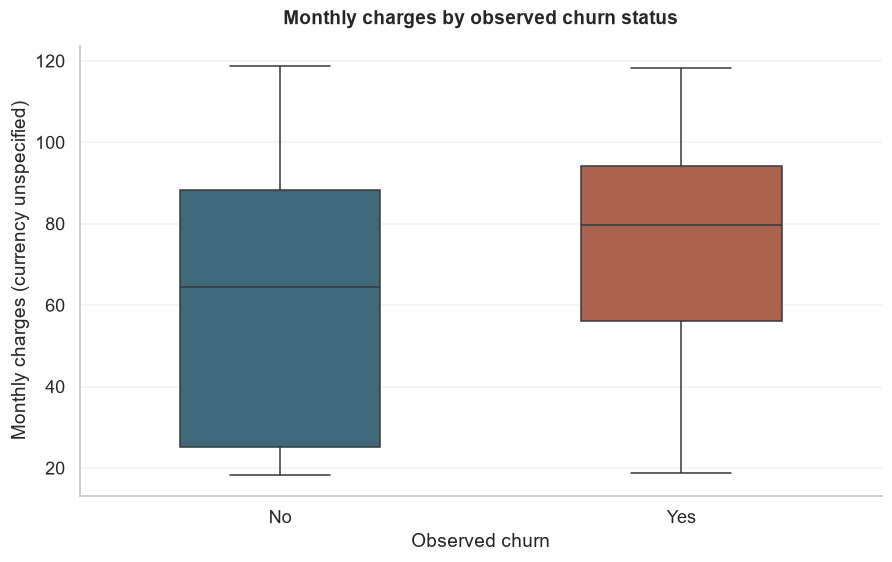

,Customers,Mean,Median
Churn,,,
No,5174,61.270,64.430
Yes,1869,74.440,79.650


Churned customers have mean monthly charges of **74.44**, compared with **61.27** for non-churned customers. Service mix and customer characteristics may contribute to this association.

In [9]:
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", order=["No", "Yes"],
            hue_order=["No", "Yes"], palette={"No": RETAINED_COLOR, "Yes": CHURN_COLOR},
            legend=False, width=0.5, ax=ax)
ax.set(title="Monthly charges by observed churn status", xlabel="Observed churn", ylabel="Monthly charges (currency unspecified)")
plt.show()
charge_summary = df.groupby("Churn")["MonthlyCharges"].agg(Customers="size", Mean="mean", Median="median")
display(charge_summary.round(2))
display(Markdown(
    f"Churned customers have mean monthly charges of **{charge_summary.loc['Yes', 'Mean']:.2f}**, "
    f"compared with **{charge_summary.loc['No', 'Mean']:.2f}** for non-churned customers. "
    "Service mix and customer characteristics may contribute to this association."
))

#### Figure 5. Service and payment comparisons
These panels compare internet service, payment method, and technical support. Internet
availability is retained as a separate category, rather than treating it as a missing value.
Payment-method differences are a reason to investigate billing experience, not proof
that changing a payment method will prevent churn.

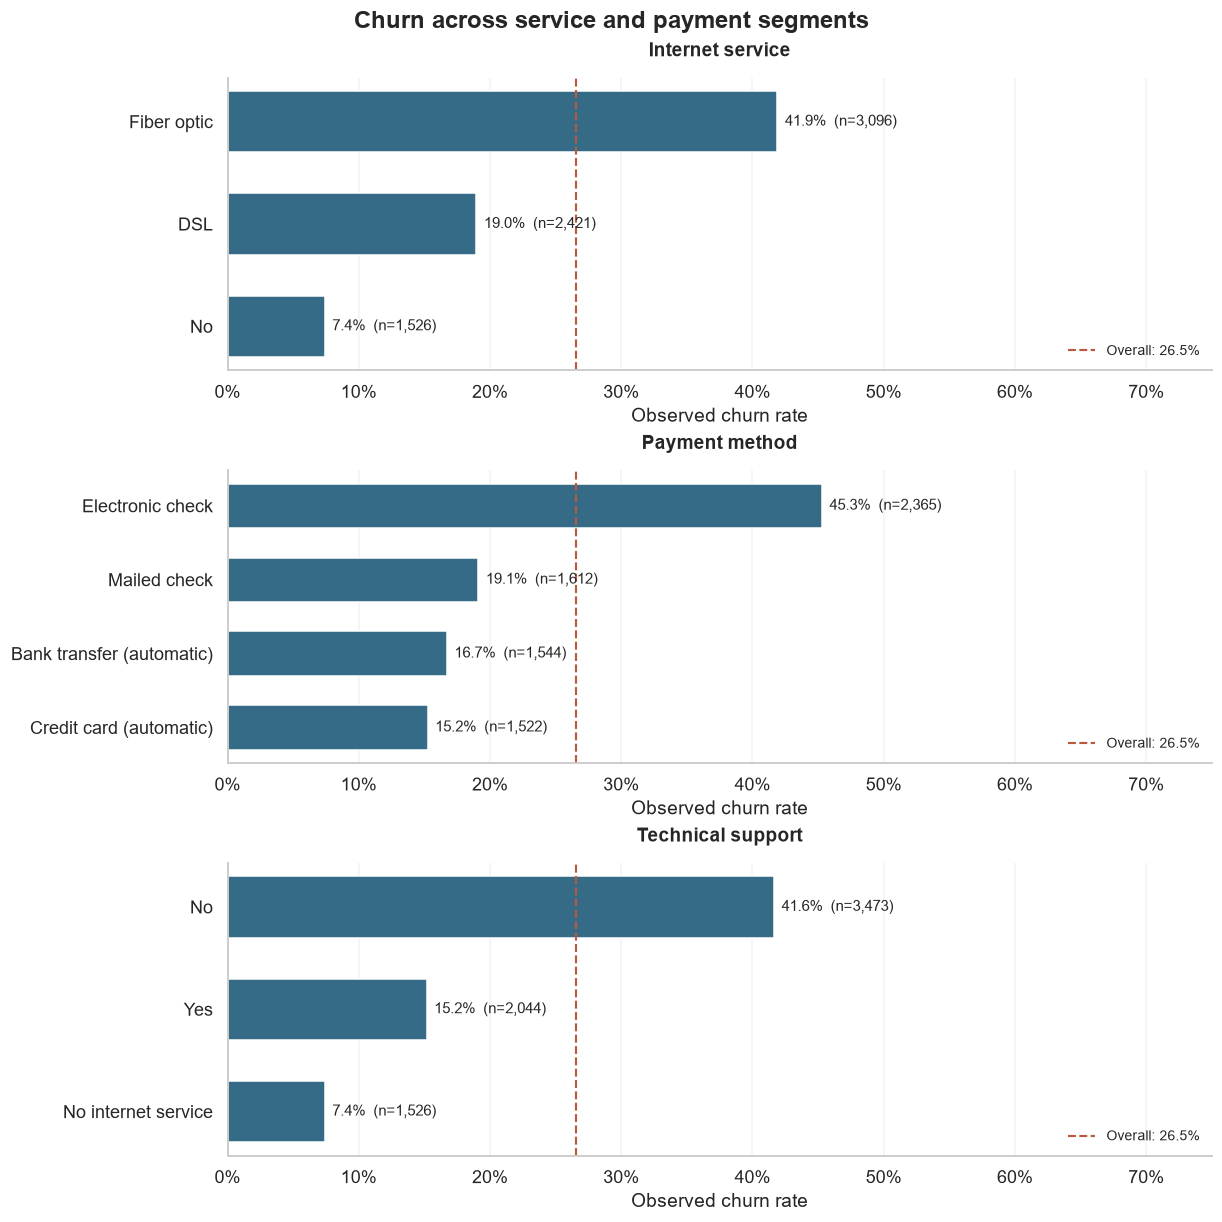

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(11, 11), layout="constrained")
for ax, column, title in zip(
    axes,
    ["InternetService", "PaymentMethod", "TechSupport"],
    ["Internet service", "Payment method", "Technical support"],
):
    plot_segment_rates(segment_summary(column).sort_values("ChurnRate", ascending=False), ax, title)
fig.suptitle("Churn across service and payment segments", fontsize=16, fontweight="bold")
plt.show()

### 7. Key churn associations
The table below compares customer groups with the full-dataset rate. **Lift** is a
group's churn rate divided by the overall rate; **rate difference** is measured in
percentage points. These are unadjusted associations, not independent causal drivers.
Related features can describe the same customers.

In [11]:
association_tables = []
for column in ["Contract", "TenureBand", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity"]:
    summary = segment_summary(column).reset_index().rename(columns={column: "Segment"})
    summary.insert(0, "Feature", column)
    association_tables.append(summary)
associations = pd.concat(association_tables, ignore_index=True)
associations["RateDifferencePP"] = (associations["ChurnRate"] - observed_churn_rate) * 100
associations["Lift"] = associations["ChurnRate"] / observed_churn_rate
associations = associations.sort_values("ChurnRate", ascending=False).reset_index(drop=True)
show_table(associations, {
    "Customers": "{:,.0f}", "Churned": "{:,.0f}", "ChurnRate": "{:.2%}",
    "RateDifferencePP": "{:+.2f}", "Lift": "{:.2f}",
}, index=False)

numeric_correlations = df[numerical_features].corr()
display(Markdown("**Predictor correlations:** tenure and accumulated charges can share information. This matters when interpreting coefficients later."))
display(numeric_correlations.round(3))

Feature,Segment,Customers,Churned,ChurnRate,RateDifferencePP,Lift
TenureBand,0–12 months,"2,186","1,037",47.44%,+20.90,1.79
PaymentMethod,Electronic check,"2,365","1,071",45.29%,+18.75,1.71
Contract,Month-to-month,"3,875","1,655",42.71%,+16.17,1.61
InternetService,Fiber optic,"3,096","1,297",41.89%,+15.36,1.58
OnlineSecurity,No,"3,498","1,461",41.77%,+15.23,1.57
TechSupport,No,"3,473","1,446",41.64%,+15.10,1.57
TenureBand,13–24 months,"1,024",294,28.71%,+2.17,1.08
TenureBand,25–48 months,"1,594",325,20.39%,-6.15,0.77
PaymentMethod,Mailed check,"1,612",308,19.11%,-7.43,0.72
InternetService,DSL,"2,421",459,18.96%,-7.58,0.71


**Predictor correlations:** tenure and accumulated charges can share information. This matters when interpreting coefficients later.

,tenure,MonthlyCharges,TotalCharges
tenure,1.000,0.248,0.826
MonthlyCharges,0.248,1.000,0.651
TotalCharges,0.826,0.651,1.000


### 8. Risk segments and retention opportunities
These business segments use observed customer characteristics, not model probabilities.
They help define pilot audiences before predictive prioritization. Segments overlap, so
their customer counts must not be added. Average monthly charges indicate account scale,
not profit or the expected financial benefit of an intervention.

In [12]:
segment_masks = {
    "Early tenure, month-to-month": df["tenure"].le(12) & df["Contract"].eq("Month-to-month"),
    "Fiber optic, no technical support": df["InternetService"].eq("Fiber optic") & df["TechSupport"].eq("No"),
    "Electronic check, month-to-month": df["PaymentMethod"].eq("Electronic check") & df["Contract"].eq("Month-to-month"),
}
opportunities = {
    "Early tenure, month-to-month": "Pilot onboarding and early service check-ins",
    "Fiber optic, no technical support": "Investigate service friction and offer support access",
    "Electronic check, month-to-month": "Review billing friction and explain payment options",
}
risk_segment_rows = []
for segment, mask in segment_masks.items():
    group = df.loc[mask]
    risk_segment_rows.append({
        "Segment": segment, "Customers": len(group), "Churned": int(group["ChurnFlag"].sum()),
        "ObservedChurnRate": group["ChurnFlag"].mean(),
        "AverageMonthlyCharges": group["MonthlyCharges"].mean(),
        "Opportunity": opportunities[segment],
    })
risk_segments = pd.DataFrame(risk_segment_rows).sort_values("ObservedChurnRate", ascending=False)
show_table(risk_segments, {
    "Customers": "{:,.0f}", "Churned": "{:,.0f}", "ObservedChurnRate": "{:.2%}",
    "AverageMonthlyCharges": "{:.2f}",
}, index=False)

Segment,Customers,Churned,ObservedChurnRate,AverageMonthlyCharges,Opportunity
"Electronic check, month-to-month","1,850",994,53.73%,74.99,Review billing friction and explain payment options
"Early tenure, month-to-month","1,994","1,024",51.35%,58.22,Pilot onboarding and early service check-ins
"Fiber optic, no technical support","2,230","1,101",49.37%,87.74,Investigate service friction and offer support access


### 9. Prediction preparation
Use the original customer attributes as predictors. Exclude `customerID`, `Churn`, and
all analytical derivatives of the target. `TenureBand` is also excluded because the
model uses original tenure. `Churn = Yes` is the positive class (1).

The split is **80% training / 20% test**, stratified by churn, with `random_state = 42`.
The test set is used for final evaluation and held-out ranking only. We do not tune
features, hyperparameters, class weights, or the threshold against test performance.

In [13]:
X = df[feature_columns].copy()
y = df["ChurnFlag"].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
assert X_train.index.intersection(X_test.index).empty
assert not {"customerID", "Churn", "ChurnFlag", "TenureBand"}.intersection(X.columns)
split_summary = pd.DataFrame({
    "Split": ["Training", "Held-out test"],
    "Customers": [len(X_train), len(X_test)],
    "Churned": [int(y_train.sum()), int(y_test.sum())],
    "ChurnRate": [y_train.mean(), y_test.mean()],
})
show_table(split_summary, {"Customers": "{:,.0f}", "Churned": "{:,.0f}", "ChurnRate": "{:.2%}"}, index=False)

Split,Customers,Churned,ChurnRate
Training,"5,634","1,495",26.54%
Held-out test,"1,409",374,26.54%


### 10. Logistic Regression and majority-class baseline
Logistic Regression is appropriate for a binary outcome and offers interpretable
coefficients. Standardization puts numerical predictors on a comparable scale.
One-hot encoding represents each categorical predictor; one reference category per
feature is omitted. Reference categories are displayed with the coefficient analysis.

The preprocessing steps and classifier are joined in a **Pipeline**. Calling `fit`
only on training data learns the scaler, categories, and model without fitting on the
test set. The model uses regularization (`C = 1.0`) and an iteration limit of 2,000.
No resampling or class weighting is applied. A `DummyClassifier` that always predicts
the training majority class provides a simple comparison on the same test customers.

In [14]:
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numerical_features),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])
model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(C=1.0, solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE)),
])
model.fit(X_train, y_train)

positive_class_index = list(model.classes_).index(1)
test_probabilities = model.predict_proba(X_test)[:, positive_class_index]
test_predictions = (test_probabilities >= THRESHOLD).astype(int)

baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_predictions = baseline.predict(X_test)
baseline_probabilities = baseline.predict_proba(X_test)[:, list(baseline.classes_).index(1)]
iterations_used = int(model.named_steps["classifier"].n_iter_.max())
print(f"Logistic Regression fitted in {iterations_used} iterations.")
print(f"Decision rule: predict churn when probability >= {THRESHOLD:.2f}.")

Logistic Regression fitted in 40 iterations.
Decision rule: predict churn when probability >= 0.50.


### 11. Held-out model evaluation
- **Accuracy:** fraction of all test customers classified correctly.
- **Precision:** fraction of predicted churners who actually churned.
- **Recall:** fraction of actual churners identified.
- **F1-score:** harmonic mean of churn precision and recall.
- **ROC-AUC:** ability to rank churners above non-churners across thresholds; calculated
  from probabilities, not the 0/1 predictions.

All classification metrics use the fixed threshold of 0.50 and `Yes` as the positive
class. Baseline precision is reported as zero by convention when no churn is predicted.

In [15]:
def evaluate_classifier(actual, predicted, probabilities):
    return {
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(actual, predicted, pos_label=1, zero_division=0),
        "Recall": recall_score(actual, predicted, pos_label=1, zero_division=0),
        "F1-score": f1_score(actual, predicted, pos_label=1, zero_division=0),
        "ROC-AUC": roc_auc_score(actual, probabilities),
    }

metrics = pd.DataFrame({
    "Majority-class baseline": evaluate_classifier(y_test, baseline_predictions, baseline_probabilities),
    "Logistic Regression": evaluate_classifier(y_test, test_predictions, test_probabilities),
}).T
show_table(metrics, {column: "{:.4f}" for column in metrics.columns})

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Majority-class baseline,0.7346,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.8062,0.6593,0.5588,0.6049,0.8422


#### Figure 6. Confusion matrix
Rows are actual outcomes and columns are predicted outcomes. A false negative is a
missed churner; a false positive could result in unnecessary retention contact. The
relative costs are not supplied, so the threshold is not described as cost-optimal.

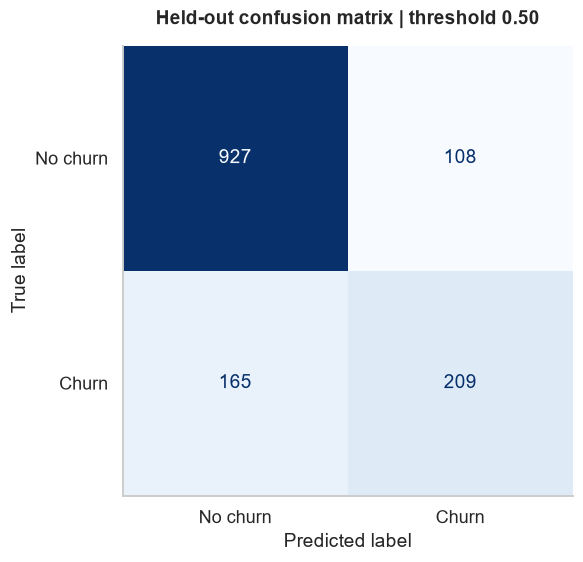

The model identifies **209** churners and misses **165**. It flags **108** non-churners and correctly classifies **927** non-churners. Recall is **55.88%** and precision is **65.93%**.

In [16]:
cm = confusion_matrix(y_test, test_predictions, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
fig, ax = plt.subplots(figsize=(6.5, 5), layout="constrained")
ConfusionMatrixDisplay(cm, display_labels=["No churn", "Churn"]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d",
)
ax.set_title(f"Held-out confusion matrix | threshold {THRESHOLD:.2f}")
ax.grid(False)
plt.show()
display(Markdown(
    f"The model identifies **{tp:,}** churners and misses **{fn:,}**. "
    f"It flags **{fp:,}** non-churners and correctly classifies **{tn:,}** non-churners. "
    f"Recall is **{metrics.loc['Logistic Regression', 'Recall']:.2%}** and precision is "
    f"**{metrics.loc['Logistic Regression', 'Precision']:.2%}**."
))

#### Figure 7. ROC curve
ROC-AUC summarizes ranking discrimination. It does not establish that the probabilities
are calibrated or that a retention campaign will be profitable. A constant-score
majority baseline has no ranking discrimination.

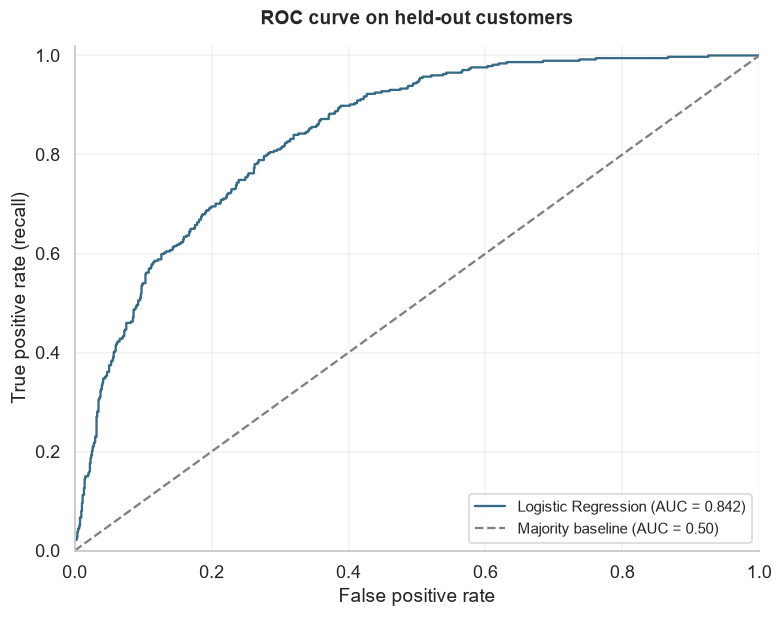

In [17]:
fig, ax = plt.subplots(figsize=(7, 5.5), layout="constrained")
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_probabilities, pos_label=1)
ax.plot(false_positive_rate, true_positive_rate, color=RETAINED_COLOR,
        label=f"Logistic Regression (AUC = {metrics.loc['Logistic Regression', 'ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label=f"Majority baseline (AUC = {metrics.loc['Majority-class baseline', 'ROC-AUC']:.2f})")
ax.set(title="ROC curve on held-out customers", xlabel="False positive rate", ylabel="True positive rate (recall)", xlim=(0, 1), ylim=(0, 1.02))
ax.legend(loc="lower right", fontsize=10)
plt.show()

### 12. Model interpretation, held-out risk ranking, and final KPIs
#### Figure 8. Logistic Regression coefficients
A positive coefficient is associated with higher modeled churn log-odds; a negative
coefficient is associated with lower log-odds, conditional on the other included
predictors. Categorical coefficients compare a category with its displayed reference.
Numerical coefficients describe a one-training-standard-deviation increase.

These regularized coefficients are **not causal effects, significance tests, or a
universal feature-importance ranking**. Correlated inputs can share or offset their
coefficients. In particular, accumulated charges, tenure, monthly charges, and service
indicators should be interpreted together. Odds ratios are not probability differences.

,Feature,Reference category
0,gender,Female
1,SeniorCitizen,0
2,Partner,No
3,Dependents,No
4,PhoneService,No
5,MultipleLines,No
6,InternetService,DSL
7,OnlineSecurity,No
8,OnlineBackup,No
9,DeviceProtection,No


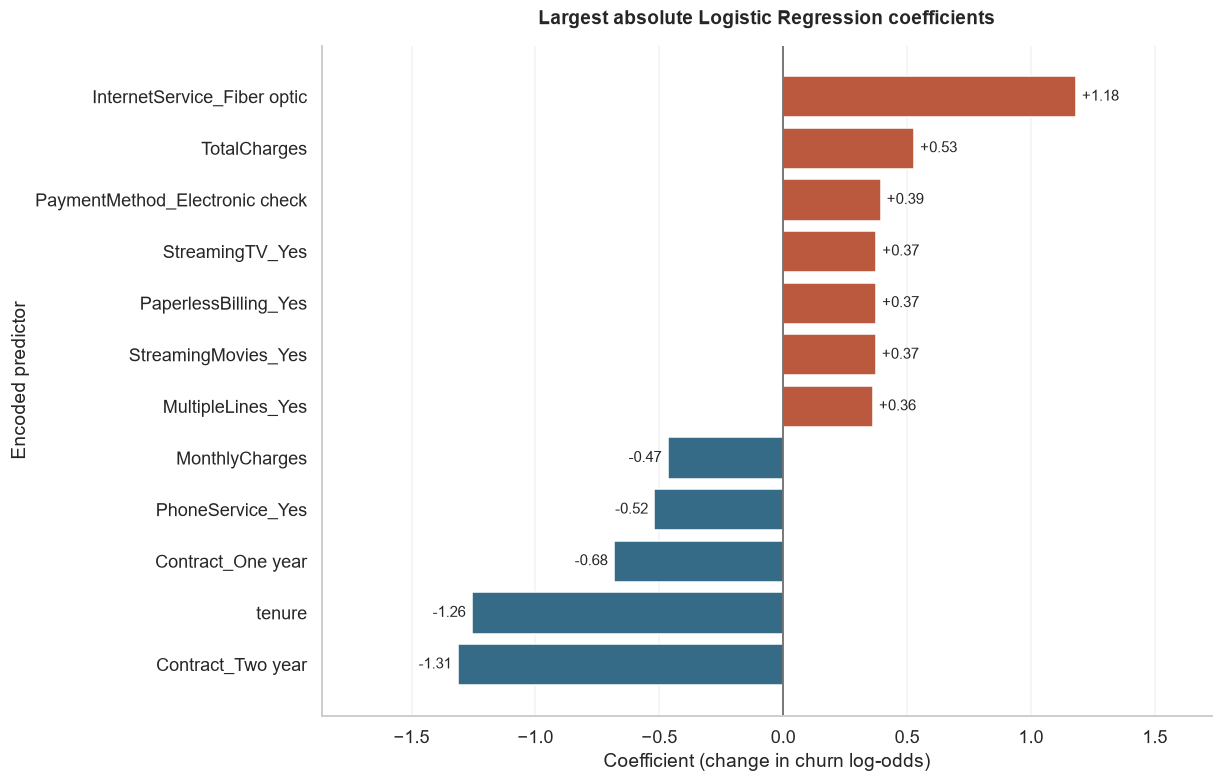

,Feature,Coefficient,OddsRatio
0,Contract_Two year,-1.314,0.269
1,tenure,-1.257,0.284
2,InternetService_Fiber optic,1.181,3.257
3,Contract_One year,-0.684,0.505
4,TotalCharges,0.528,1.695
5,PhoneService_Yes,-0.521,0.594
6,MonthlyCharges,-0.467,0.627
7,PaymentMethod_Electronic check,0.393,1.481
8,StreamingTV_Yes,0.375,1.455
9,PaperlessBilling_Yes,0.374,1.454


In [18]:
fitted_preprocessor = model.named_steps["preprocess"]
encoder = fitted_preprocessor.named_transformers_["categorical"]
reference_categories = pd.DataFrame({
    "Feature": categorical_features,
    "Reference category": [categories[drop_index] for categories, drop_index in zip(encoder.categories_, encoder.drop_idx_)],
})
display(reference_categories)

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = pd.DataFrame({
    "Feature": [name.replace("numeric__", "").replace("categorical__", "") for name in feature_names],
    "Coefficient": model.named_steps["classifier"].coef_[0],
})
coefficients["OddsRatio"] = np.exp(coefficients["Coefficient"])
coefficients["AbsoluteCoefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("AbsoluteCoefficient", ascending=False).reset_index(drop=True)
coefficient_display = coefficients.head(12).sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(11, 7), layout="constrained")
colors = [CHURN_COLOR if value > 0 else RETAINED_COLOR for value in coefficient_display["Coefficient"]]
bars = ax.barh(coefficient_display["Feature"], coefficient_display["Coefficient"], color=colors)
ax.bar_label(bars, fmt="%+.2f", padding=4, fontsize=10)
ax.axvline(0, color="#555555", linewidth=1)
ax.margins(x=0.22)
ax.set(title="Largest absolute Logistic Regression coefficients", xlabel="Coefficient (change in churn log-odds)", ylabel="Encoded predictor")
ax.grid(axis="y", visible=False)
plt.show()
display(coefficients.head(12).drop(columns="AbsoluteCoefficient").round(3))

#### Held-out customer risk ranking
Score only the test customers with the trained pipeline. **High risk means predicted
churn probability ≥ 0.50**, including equality. Keep customer IDs for traceability,
but never use them as predictors. Sorting uses model probability only, with customer
ID as a deterministic tie-breaker. Actual outcomes are attached afterward for evaluation.

The first table is a retrospective demonstration, not a live outreach list: this
dataset already includes churn outcomes. A future campaign would need a current,
eligible customer population, a prediction horizon, and validation on later data.

In [19]:
risk_ranking = df.loc[X_test.index, ["customerID", "Contract", "tenure", "MonthlyCharges"]].copy()
risk_ranking["PredictedChurnProbability"] = test_probabilities
risk_ranking["HighRisk"] = risk_ranking["PredictedChurnProbability"].ge(THRESHOLD)
risk_ranking = risk_ranking.sort_values(
    ["PredictedChurnProbability", "customerID"], ascending=[False, True]
)
risk_ranking["ActualChurn"] = y_test.loc[risk_ranking.index].map({0: "No", 1: "Yes"})
risk_ranking.insert(0, "Rank", np.arange(1, len(risk_ranking) + 1))
high_risk_count = int(risk_ranking["HighRisk"].sum())
show_table(risk_ranking.head(15), {
    "MonthlyCharges": "{:.2f}", "PredictedChurnProbability": "{:.2%}",
}, index=False)

risk_summary = risk_ranking.groupby("HighRisk").agg(
    Customers=("customerID", "size"),
    MeanPredictedProbability=("PredictedChurnProbability", "mean"),
    ObservedChurnRate=("ActualChurn", lambda outcomes: outcomes.eq("Yes").mean()),
    AverageMonthlyCharges=("MonthlyCharges", "mean"),
).rename(index={False: "Below 0.50", True: "High risk: at least 0.50"})
show_table(risk_summary, {
    "Customers": "{:,.0f}", "MeanPredictedProbability": "{:.2%}",
    "ObservedChurnRate": "{:.2%}", "AverageMonthlyCharges": "{:.2f}",
})
display(Markdown(
    f"**{high_risk_count:,} of {len(X_test):,} held-out customers "
    f"({high_risk_count / len(X_test):.2%})** meet the high-risk threshold. "
    f"Of these, **{tp:,}** are observed churners and **{fp:,}** are non-churners. "
    "The count is not extrapolated to the full dataset."
))

Rank,customerID,Contract,tenure,MonthlyCharges,PredictedChurnProbability,HighRisk,ActualChurn
1,5178-LMXOP,Month-to-month,1,95.10,85.53%,True,Yes
2,0295-PPHDO,Month-to-month,1,95.45,83.22%,True,Yes
3,6861-XWTWQ,Month-to-month,7,99.25,82.79%,True,Yes
4,8884-ADFVN,Month-to-month,7,101.95,82.30%,True,Yes
5,1069-XAIEM,Month-to-month,1,85.05,81.94%,True,Yes
6,9057-SIHCH,Month-to-month,3,96.60,81.85%,True,Yes
7,6023-YEBUP,Month-to-month,3,100.95,81.78%,True,Yes
8,1400-MMYXY,Month-to-month,3,105.90,81.77%,True,Yes
9,2545-EBUPK,Month-to-month,2,84.05,81.76%,True,No
10,6630-UJZMY,Month-to-month,4,83.25,81.19%,True,No


,Customers,MeanPredictedProbability,ObservedChurnRate,AverageMonthlyCharges
HighRisk,,,,
Below 0.50,"1,092",15.85%,15.11%,59.68
High risk: at least 0.50,317,64.41%,65.93%,79.26


**317 of 1,409 held-out customers (22.50%)** meet the high-risk threshold. Of these, **209** are observed churners and **108** are non-churners. The count is not extrapolated to the full dataset.

#### Final five headline KPIs
The population column is essential: the high-risk KPI covers only held-out customers,
while the other KPIs describe the entire snapshot. Values are calculated from the
cleaned data and the actual held-out probabilities, not manually entered results.

In [20]:
final_kpis = pd.DataFrame({
    "KPI": ["Total Customers", "Observed Churn Rate", "Average Monthly Charges", "Average Tenure", "High-Risk Customer Count"],
    "Value": [f"{total_customers:,}", f"{observed_churn_rate:.2%}",
              f"{average_monthly_charges:.2f} charge units", f"{average_tenure:.2f} months", f"{high_risk_count:,}"],
    "Population": ["Full dataset"] * 4 + [f"Held-out test set ({len(X_test):,} customers); probability >= {THRESHOLD:.2f}"],
})
display(final_kpis)

,KPI,Value,Population
0,Total Customers,"7,043",Full dataset
1,Observed Churn Rate,26.54%,Full dataset
2,Average Monthly Charges,64.76 charge units,Full dataset
3,Average Tenure,32.37 months,Full dataset
4,High-Risk Customer Count,317,"Held-out test set (1,409 customers); probability >= 0.50"


### 13. Evidence-based recommendations
The recommendations below are hypotheses to test. Each numerical observation is
calculated from the dataset. A controlled pilot with a comparison group is needed to
learn whether an intervention improves retention. Prioritize service and account needs;
demographic characteristics alone should not determine access to retention support.

In [21]:
early_rate = tenure_summary.iloc[0]["ChurnRate"]
month_to_month_rate = contract_summary.loc["Month-to-month", "ChurnRate"]
fiber_rate = segment_summary("InternetService").loc["Fiber optic", "ChurnRate"]
electronic_rate = segment_summary("PaymentMethod").loc["Electronic check", "ChurnRate"]

recommendations = pd.DataFrame([
    {
        "Priority": 1, "Action": "Pilot early-tenure onboarding and service check-ins",
        "Evidence": f"Churn is {early_rate:.2%} at tenure 0–12 months versus {observed_churn_rate:.2%} overall.",
        "Opportunity": "Resolve setup or expectation issues earlier",
        "Measure": "Retention over a predefined follow-up period versus a randomized comparison group",
    },
    {
        "Priority": 2, "Action": "Test optional contract offers for suitable month-to-month customers",
        "Evidence": f"Month-to-month churn is {month_to_month_rate:.2%} among {contract_summary.loc['Month-to-month', 'Customers']:,.0f} customers.",
        "Opportunity": "Evaluate whether voluntary offers improve retention without excessive discounting",
        "Measure": "Incremental retention, offer uptake, and incentive cost per additional retained customer",
    },
    {
        "Priority": 3, "Action": "Investigate fiber-service experience and support access",
        "Evidence": f"Fiber optic churn is {fiber_rate:.2%}; the service/support segment table identifies an audience for investigation.",
        "Opportunity": "Use complaint and service-quality data to identify fixable friction",
        "Measure": "Issue resolution and subsequent retention versus a comparable untreated group",
    },
    {
        "Priority": 4, "Action": "Review billing friction and explain available payment options",
        "Evidence": f"Electronic-check churn is {electronic_rate:.2%}; this is an association, not a payment-method effect.",
        "Opportunity": "Test clearer billing and optional payment assistance",
        "Measure": "Billing complaints, failed payments, and incremental retention in a pilot",
    },
    {
        "Priority": 5, "Action": "Validate a probability-ranked outreach pilot on current eligible customers",
        "Evidence": f"At probability >= {THRESHOLD:.2f}, {high_risk_count:,} of {len(X_test):,} test customers are flagged; precision is {metrics.loc['Logistic Regression', 'Precision']:.2%}.",
        "Opportunity": "Match outreach capacity to risk while monitoring missed churners",
        "Measure": "Incremental retained customers, contact cost, opt-outs, and outcomes by customer group",
    },
])
show_table(recommendations, index=False)

Priority,Action,Evidence,Opportunity,Measure
1,Pilot early-tenure onboarding and service check-ins,Churn is 47.44% at tenure 0–12 months versus 26.54% overall.,Resolve setup or expectation issues earlier,Retention over a predefined follow-up period versus a randomized comparison group
2,Test optional contract offers for suitable month-to-month customers,"Month-to-month churn is 42.71% among 3,875 customers.",Evaluate whether voluntary offers improve retention without excessive discounting,"Incremental retention, offer uptake, and incentive cost per additional retained customer"
3,Investigate fiber-service experience and support access,Fiber optic churn is 41.89%; the service/support segment table identifies an audience for investigation.,Use complaint and service-quality data to identify fixable friction,Issue resolution and subsequent retention versus a comparable untreated group
4,Review billing friction and explain available payment options,"Electronic-check churn is 45.29%; this is an association, not a payment-method effect.",Test clearer billing and optional payment assistance,"Billing complaints, failed payments, and incremental retention in a pilot"
5,Validate a probability-ranked outreach pilot on current eligible customers,"At probability >= 0.50, 317 of 1,409 test customers are flagged; precision is 65.93%.",Match outreach capacity to risk while monitoring missed churners,"Incremental retained customers, contact cost, opt-outs, and outcomes by customer group"


### Limitations
- **Snapshot, not a forecast:** no observation dates, event timestamps, or future churn
  horizon are supplied. A random holdout measures discrimination within this dataset,
  not performance on future customers. Feature availability at a real scoring date is unverified.
- **Associations, not causes:** contracts, service choices, and payments may reflect
  customer selection and unmeasured factors. An offer or service change is not guaranteed
  to improve retention.
- **Missing-charge assumption:** zero replaces missing accumulated charges only at zero
  tenure. Billing records would be needed to confirm the assumption.
- **Model limits:** Logistic Regression is linear in log-odds. Correlated and structurally
  related features can make individual coefficients unstable or counterintuitive.
- **Evaluation limits:** results use one reproducible split. No confidence intervals,
  probability-calibration assessment, external validation, or subgroup performance audit
  are provided. The 0.50 threshold is specified, not optimized for intervention costs.
- **Risk-count scope:** only held-out test customers are scored for the headline high-risk
  count. Already-churned records must not become a real retention contact list.
- **Business limits:** currency, margins, campaign costs, treatment effects, and detailed
  churn reasons are unavailable. No realized revenue loss, savings, or return on investment
  is claimed. Demographic predictors require fairness review before operational use.
- **Provenance:** analysis uses the CSV supplied with the project. The repository provides
  no accompanying source or license documentation; no external provenance is asserted here.

### Conclusion
The following summary is generated directly from the calculated KPIs and test results.

In [22]:
display(Markdown(
    f"The snapshot contains **{total_customers:,} customers** with **{observed_churn_rate:.2%} observed churn**. "
    f"Early-tenure customers have **{early_rate:.2%}** churn and month-to-month customers have "
    f"**{month_to_month_rate:.2%}**, supporting focused investigation and retention pilots.\n\n"
    f"On **{len(X_test):,} held-out customers**, Logistic Regression achieves "
    f"**{metrics.loc['Logistic Regression', 'Accuracy']:.2%} accuracy**, "
    f"**{metrics.loc['Logistic Regression', 'Precision']:.2%} precision**, "
    f"**{metrics.loc['Logistic Regression', 'Recall']:.2%} recall**, "
    f"**{metrics.loc['Logistic Regression', 'F1-score']:.4f} F1**, and "
    f"**{metrics.loc['Logistic Regression', 'ROC-AUC']:.4f} ROC-AUC**. "
    f"Majority-baseline accuracy is **{metrics.loc['Majority-class baseline', 'Accuracy']:.2%}**.\n\n"
    f"The model flags **{high_risk_count:,} held-out customers** at probability ≥ {THRESHOLD:.2f}. "
    "Use the analysis to design controlled onboarding, support, contract, and billing pilots. "
    "Validate on later, eligible customers before operational use; neither the associations "
    "nor the classifier establishes the effect of an intervention."
))

The snapshot contains **7,043 customers** with **26.54% observed churn**. Early-tenure customers have **47.44%** churn and month-to-month customers have **42.71%**, supporting focused investigation and retention pilots.

On **1,409 held-out customers**, Logistic Regression achieves **80.62% accuracy**, **65.93% precision**, **55.88% recall**, **0.6049 F1**, and **0.8422 ROC-AUC**. Majority-baseline accuracy is **73.46%**.

The model flags **317 held-out customers** at probability ≥ 0.50. Use the analysis to design controlled onboarding, support, contract, and billing pilots. Validate on later, eligible customers before operational use; neither the associations nor the classifier establishes the effect of an intervention.

### Reproducibility checks
These checks verify row preservation, the missing-charge rule, split separation,
training-only scaler statistics, classification threshold, ranking alignment, and
confusion-matrix totals. They check the integrity of the analysis rather than asserting
that the model must achieve a predetermined score.

In [23]:
assert len(raw) == len(df) == len(X_train) + len(X_test)
assert cleaned_charge_count == int(blank_counts["TotalCharges"] + raw["TotalCharges"].isna().sum())
assert df.loc[zero_tenure_missing, "TotalCharges"].eq(0).all()
assert df.loc[zero_tenure_missing, "tenure"].eq(0).all()
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_train.index).union(X_test.index) == set(df.index)
scaler = fitted_preprocessor.named_transformers_["numeric"]
np.testing.assert_allclose(scaler.mean_, X_train[numerical_features].mean().to_numpy())
assert int(scaler.n_samples_seen_) == len(X_train)
assert np.isfinite(test_probabilities).all()
assert ((test_probabilities >= 0) & (test_probabilities <= 1)).all()
np.testing.assert_array_equal(test_predictions, (test_probabilities >= THRESHOLD).astype(int))
np.testing.assert_allclose(risk_ranking.loc[X_test.index, "PredictedChurnProbability"], test_probabilities)
assert set(risk_ranking.index) == set(X_test.index)
assert risk_ranking["PredictedChurnProbability"].is_monotonic_decreasing
assert high_risk_count == int((test_probabilities >= THRESHOLD).sum()) == int(tp + fp)
assert int(cm.sum()) == len(y_test) and int(tp + fn) == int(y_test.sum())
assert iterations_used < model.named_steps["classifier"].max_iter
assert len(final_kpis) == 5
print("All reproducibility checks passed.")

All reproducibility checks passed.
